## Report : Automated Sleep Stage Classification Using the Dreem Headband

### Authors : Laure Gicquel and Elara Sauget

Sleep is a complex and essential physiological process in many health aspects. During sleep, the body undertakes critical restorative functions, including muscle growth, tissue repair, protein synthesis, and hormone release. However, it is not a uniform state but progresses through multiple stages, each characterized by physiological patterns:
- **Wakefulness** : marked by beta waves during eye-open wakefulness and alpha waves during relaxed wakefulness with closed eyes.
- **Light sleep (N1)** : (5% of total sleep) It's the lightest sleep stage, characterized by theta waves. This stage involves a transition from alpha to low-amplitude mixed-frequency (LAMF) activity, with regular breathing and muscle tone present.
- **Mid-deep sleep (N2)**: (45% of total sleep) This deeper sleep stage is identified by sleep spindles and K complexes, playing a role in memory consolidation. Heart rate and body temperature drop, and it's the stage where bruxism (teeth grinding) occurs.
- **Deep sleep (N3)**: (25% of total sleep): Known as slow-wave sleep (SWS), this stage features delta waves. It's the hardest stage to be awakened from and involves significant body repair and growth, as well as phenomena like sleepwalking and night terrors.
- **REM (Rapid Eye Movement) sleep**: (25% of total sleep): Characterized by beta waves similar to wakefulness, REM is associated with dreaming, irregular breathing, and atonia (lack of muscle tone) except for eye and diaphragmatic muscles. REM periods lengthen throughout the night, involving dreaming and physiological reactions.


Each of these stages contributes to the body's overall rest and repair processes, with approximately 75% of sleep spent in the NREM stages. A typical night's sleep involves 4 to 5 cycles of these stages, with each cycle lasting about 90 to 110 minutes. The progression usually goes from N1 to N2, N3, back to N2, and then REM. As the night progresses, REM periods become longer while deep sleep (NREM) decreases (1).

Studying these stages allows to understand overall sleep quality, diagnose sleep disorders, and assess the impact of different health conditions on sleep. This project focuses on exploring machine learning algorithms for automated sleep stage classification using the Dreem headband. The Dreem headband is designed for at-home polysomnography and record
- brain wave activity using **electroencephalogram (EEG) Sensors** on five channels, sampled at 250Hz.
- head movements with an **accelerometer** on three-axis sampled at 50Hz.

It should be noted records contains artefacts linked to movement and EOG (especially in REM sleep), that must be compensated for feature extraction.

Dataset in this project contains multiple records, with each record containing first the five eeg channels then the accelerometer data. Records are split into epochs of 30 seconds. Each epoch has an index and can be accessed as `record * 10,000 + index`. The goal is to categorize each epoch into one of five sleep stages : 0: Wake, 1: N1, 2: N2, 3: N3, 4: REM.

The dataset includes:
- `training_records`: Raw EEG and accelerometer data for training.
- `test_records`: Raw data for testing.
- `targets_train.csv`: Training dataset targets with sleep stage labels.
- `sample.csv`: Sample submission file format.

### Preprocessing and Feature Extraction

#### EEG Signal Processing
Identify the various sleep stages requires first a **Power Spectral Density (PSD) extraction** to get spectral energy distribution over time using the Welch method (`scipy.signal.welch`). Then the **relative spectral power** in specific frequency bands (delta, theta, alpha, sigma, beta) is calculated by dividing the power in each band by the total power across all bands, providing a relative measure of power in each band.

#### Statistical Analysis
**Basic statistics**, such as standard deviation, mean, and variance for each EEG channel and accelerometer axis helps identify trends in both EEG and accelerometer data. For **higher-order statistics**, skewness for each channel and axis measures the asymmetry of the probability distribution, while kurtosis indicates the 'tailedness' of the distribution. The **Interquartile range (IQR)** is calculated to understand the spread of the middle 50% of the data, decreasing the influence of outliers.

**Spectral features** like entropy, spectral edge frequency, and other custom features are derived from the PSD. These features help in differentiating between various sleep stages based on the EEG signal characteristics.
Finally, **aggregating features** across different epochs and channels to create a comprehensive feature set for each 30-second window of data.


### Training
The XGBoost (eXtreme Gradient Boosting) classifier is used for sleep stage prediction. It is a scalable, performand and fast machine learning algorithm that is particularly effective for structured or tabular data.

The first step is to **extract features**  from EEG and accelerometer data using different channels and epochs into a structured format.
Validation is done with **K-Fold cross-validation**  by dividing the dataset into 'K' folds, using each fold in turn for testing the model while training on the remaining folds. This helps in assessing the model's performance across different subsets of the data. The XGBoost classifier is then **trained** on the prepared dataset. **Parameters** of the XGBoost model like learning rate, depth of the trees, and the number of estimators have been tuneto achieve the best results.

#### Prediction and Submission
Once the model is trained and validated, it is then applied to the unseen test dataset. For each 30-second epoch, the model classifies them into a given sleep stages. Predictions are formatted as per the contest's submission guidelines, typically including an identifier (calculated as `record * 10,000 + index`) and the predicted sleep stage using the CSV format.



In [ ]:
# Importing the necessary packages
import os
import random as rd

# Data/stats manipulation, analysis, plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (
    entropy,
    kurtosis,
    skew,
    iqr,  # Interquartile
)

# YASA for sleep analysis
import yasa

# MNE for processing EEG data
import mne

# XGBoost classifier for machine learning
from xgboost import XGBClassifier

# Scipy functions for signal processing
from scipy.signal import (
    spectrogram,
    welch,  # Welch method : power spectral density
    # Scipy functions for Butterworth filter design and signal filtering
    butter,
    lfilter
)
# Classification evaluation
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    accuracy_score,
)
# Machine learning and classification
from sklearn.ensemble import RandomForestClassifier  # Random Forest Classifier
from sklearn.model_selection import (
    KFold,  # K-Fold cross-validation
    cross_val_score,  # Cross-validation scoring
    train_test_split,  # Splitting data into training and testing sets
)

import pywt


### Feature Extraction details

In this section, we introduce the functions that are used in feature extraction from the EEG and accelerometer data.

**Accelerometer data** (`accelerometer_features`) captures data on there axis (X, Y, and Z). For each axis, **basic statistics** are computed, mostly mean, standard deviation, and Signal Magnitude Area (SMA). Acceleration may be linked to the sleep movement, possibly indicating a wake state, for example.

**Spectral analysis** of EEG data (`calculate_psd`) is done with the Power Spectral Density (PSD) of EEG data. Switching to spectral components may give a simpler image of  of the EEG signal.

**Temporal features** of EEG signal (`time_domain_features`) is done with variance, kurtosis, and skewness. Variance measures the spread of data points, while kurtosis and skewness describe the shape and symmetry of the data distribution, respectively.

**Frequency bands** (`frequency_bands`) defines the frequency ranges associated with different EEG bands, such as delta, theta, alpha, sigma, and beta. We include slow theta 2-5 Hz, as it is mentioned in some studies on sleep (2). `statistics` is a set of classic statistics : mean, maximum, minimum, interquartile, standard deviation.

From spectrogram analysis of EEG data, we compute the **relative spectral power** for each of the predefined frequency bands (`get_relative_spectral_power_for_epoch`)
to understand the distribution of EEG power across different frequency components.

A limitation of spectral analysis can be mitigated with **wavelet analysis** (`wavelet_features`) that captures both time and frequency information in EEG signals. Discrete wavelet transform are used to compute wavelet coefficients, from which mean and standard deviation are computed

Two additional functions, `spectral_entropy` and `shannon_entropy`, are defined to calculate **spectral entropy** and **Shannon entropy**, respectively. Spectral entropy measures the complexity of the EEG signal's frequency distribution, while Shannon entropy quantifies the information content in the signal.

The `higher_order_acc_features` function computes higher-order statistics of accelerometer data, including skewness and kurtosis. These features provide insights into the shape and distribution of acceleration values.

Peaks often correspond to specific EEG patterns and can be indicative of sleep stages. As such the number of peaks are counted (`peak_analysis_features`).

Lastly, spindles are characteristic EEG patterns associated with sleep, and their density can be a relevant feature for sleep stage classification. So
spindle density based on the sigma frequency range (12-16 Hz) are computed (`compute_spindle`).




In [ ]:
# ----------------------------------- Dictionaries used for the extraction -------------------------------------------------------------

# All the frequency bands defined in the data. "lowtheta" correspond to slow theta waves observed mainly in people that recall their nightmares strongly, in very light stages of sleep.

frequency_bands = {

    "delta": [0.5, 4],
    "lowtheta": [2, 5],
    "theta": [4, 8],
    "alpha": [8, 12],
    "sigma": [12, 16],
    "beta": [16, 30]
    }


def calcul_psd(x, fs=250.0, nperseg=None):
    """
    Spectral power calculation
    """
    _, psd = welch(x, fs=fs, nperseg=nperseg)
    return np.apply_along_axis(np.mean, axis=1, arr=psd)


# Define all the statistical features extracted by the compute_stats function

statistics = {
    "stdev": lambda x: np.std(x, axis=1),
    "mean": lambda x: np.mean(np.abs(x), axis=1),
    "median": lambda x: np.median(x, axis=1),
    "iqr": lambda x: np.apply_along_axis(lambda arr: iqr(arr, nan_policy='omit'), axis=1, arr=x),
    "psd": calcul_psd,  # Assuming `calcul_psd` is a function defined elsewhere
    "sum": lambda x: np.sum(x, axis=1),
    "max": lambda x: np.max(x, axis=1),
    "min": lambda x: np.min(x, axis=1),
}


### -------- Functions for feature extraction from EEG and accelerometer -----------------------------

def accelerometer_features(acc_data):
    """ Extract features from 3-axis accelerometer data """
    # Split data into X, Y, Z axes
    acc_x = acc_data[:, :1500]  # X-axis data
    acc_y = acc_data[:, 1500:3000]  # Y-axis data
    acc_z = acc_data[:, 3000:]  # Z-axis data
    features = {}
    for axis, data in zip(['x', 'y', 'z'], [acc_x, acc_y, acc_z]):
        axis_mean = np.mean(data, axis=1)
        axis_std = np.std(data, axis=1)
        axis_sma = np.sum(np.abs(data), axis=1) / data.shape[1]  # Signal Magnitude Area

        # Add features to the dictionary with axis-specific keys
        features[f'acc_{axis}_mean'] = axis_mean
        features[f'acc_{axis}_std'] = axis_std
        features[f'acc_{axis}_sma'] = axis_sma

    return features




def time_domain_features(data):
    """ Compute time domain features for each epoch in the data """
    variances = np.var(data, axis=1)
    kurtoses = np.array([kurtosis(epoch) for epoch in data])
    skews = np.array([skew(epoch) for epoch in data])
    return {"variance": variances, "kurtosis": kurtoses, "skewness": skews}


def get_relative_spectral_power_for_epoch(data):
    """
    Relative spectral power for the frequency bands
    """
    #print(data.shape)
    EEG_FS = 250
    psds = []
    sfreqs,t,psd = spectrogram(data,250,nperseg = 1000,noverlap = 750)
    psd = np.mean(np.abs(psd),-1)
    #print(psd.shape)
    spectral_power_band = {}
    for name, freqband in frequency_bands.items():
        spec_power = psd[:,(sfreqs >= freqband[0]) & (sfreqs < freqband[1])]
        spec_power = np.sum(spec_power, 1)
        spectral_power_band[name] = spec_power / np.sum(psd,1)
    return spectral_power_band

def compute_stats(data):
    """
    Compute statistics of a signal based on statistics list
    """
    EEG_FS = 250
    result = {k:f(data) for k,f in statistics.items()}
    return result


def wavelet_features(eeg_data):
    """
    Extract wavelet features
    """
    features = {}
    coeffs = pywt.wavedec(eeg_data, wavelet='db4', level=5, axis=1)
    for i, coeff in enumerate(coeffs):
        features[f'wavelet_approx_{i}_mean'] = np.mean(coeff, axis=1)
        features[f'wavelet_approx_{i}_std'] = np.std(coeff, axis=1)
    return features

def spectral_entropy(data):
    """ Calculate spectral entropy for each epoch """
    spec_entropy = np.array([entropy(epoch) for epoch in data])
    return spec_entropy

def shannon_entropy(data):
    """ Calculate Shannon entropy for each epoch """
    shannon_ent = -np.sum(np.abs(data) * np.log(np.abs(data) + 1e-10), axis=1)
    return shannon_ent


def higher_order_acc_features(acc_data):
    skewness = np.apply_along_axis(skew, axis=1, arr=acc_data)
    kurtosis_val = np.apply_along_axis(kurtosis, axis=1, arr=acc_data)
    return {"acc_skewness": skewness, "acc_kurtosis": kurtosis_val}

def peak_analysis_features(eeg_data):
    peak_counts = np.array([len(find_peaks(epoch)[0]) for epoch in eeg_data])
    return {"peak_count": peak_counts}




def compute_spindle(eeg_data):
    """
    Compute relevant statistics for spindle data.
    """
    EEG_FS = 250
    SIGMA_FREQ_MIN = 12  # Min frequency of spindle (in Hz)
    SIGMA_FREQ_MAX = 16  # Max frequency of spindle (in Hz)

    # Compute the spectrogram
    sfreqs, _, psd = spectrogram(eeg_data, EEG_FS, nperseg=1000, noverlap=750)

    # Ensure correct dimension alignment
    if sfreqs.shape[0] != psd.shape[0]:
        psd = psd.T  # Transpose PSD if necessary

    # Filter the PSD values within the spindle frequency range
    sigma_mask = (sfreqs >= SIGMA_FREQ_MIN) & (sfreqs < SIGMA_FREQ_MAX)


    sigmapwr = np.sum(psd[sigma_mask, :], axis=0)

    # Compute statistics
    spindle_stats = {
        'spindle_mean': np.mean(sigmapwr),
        'spindle_std': np.std(sigmapwr),
        'spindle_max': np.max(sigmapwr),
    }

    return spindle_stats




### Extracting the features and preparing the data

This part of the code focuses on the extraction of each feature based on the functions we defined previously. After trial and error, we took out the peak analysis and entropy calculations that did not raise our accuracy and were make the cord too complex. We also tried using mne to bandpass and yasa to extract feature from the bandpassed signal but that raised a lot of dimensionality errors, so we went back to the original signal.
We initialize two data structures using dictionaries:
- `data_for_records` for extracted feature data for each record.
- `hypnogram_for_records` for hypnogram data associated with each record, that will be used as labels for the training and the validation of the model.

We load the hypnogram data from a CSV file named 'targets_train.csv` using the Pandas library. The code iterates through each record in the 'training_records' directory processing data and removing features are described below.

##### EEG Channel/Accelerometer data Processing

EEG data from each record is segmented into five distinct channels, each corresponding to a specific segment of EEG readings. For each EEG channel, we extract a set of features : spectral power, statistical metrics, time-domain characteristics, wavelet-based attributes, and spindle-related information.
The extracted features are stacked in the `data_for_records` dictionary.

Accelerometer data is isolated from the loaded record and processed with the previously defined functions. Each feature is assigned a unique key that incorporates the channel index and feature name, for record-keeping purposes.

Hypnogram data pertaining to the current record is fetched from the previously loaded CSV file ('targets_train.csv') based on the record number.

Also, a variable list (`variable_list`) is generated containing the feature names extracted for a single record, for debugging purposes and for plotting analysis.

#### Feature Removal

After initial feature analysis (MDI plotting and permutation importance), it seemed that it would be useful to eliminate some of the channel_0 features from the dataset as they were high on the right of the MDI and low on the left of the permutation graph. The features high ranking in the MDI graph suggested that they played a significant role in reducing uncertainty within the model's decision trees. However, the features low ranking in permutation importance implied that randomizing their values did not substantially impact the model’s performance. These results suggested that some features of channel 0, despite their apparent importance in the tree structure, did not have a significant influence on the model’s predictive accuracy on new data. This can lead to overfitting, or just bad predictive power for these features.
As such, we stored the three most disrupting features in a dictionary and suppressed them from the feature list. However, this was an empiric decision, there wasn't a clear cut-point in both graphs  - channel_0_mean was highest on MDI, lowest on permutation graph, but others were more debatable.


In [ ]:
# ---------------------------- Main function for feature extraction for training records ---------------------------------------------------

def main():
    data_for_records = {}
    hypnogram_for_records = {}
    hypnograms = pd.read_csv('targets_train.csv')
    print("records : " + str(os.listdir("training_records")))

    for record in os.listdir("training_records"):
        record_number = int(record[-5])
        x = np.load(f'training_records/{record}')

        # Dictionary entry for THIS record
        data_for_records[record] = {}

        # Extract data for each EEG channel
        eeg_channels = [x[:, 1:7501], x[:, 7501:15001], x[:, 15001:22501], x[:, 22501:30001], x[:, 30001:37501]]

        # Process each EEG channel
        for i, eeg_data in enumerate(eeg_channels):
            print(eeg_data.shape)
            spectral_power = get_relative_spectral_power_for_epoch(eeg_data)
            stats = compute_stats(eeg_data)
            time_features = time_domain_features(eeg_data)
            wavelet_feats = wavelet_features(eeg_data)
            #spindle_feature = compute_spindle(eeg_data)

            # Update the record's feature set with channel-specific features - prefix each feature name with the channel index
            channel_features = {**spectral_power, **stats, **time_features, **wavelet_feats}
            for feature_name, feature_value in channel_features.items():
                data_for_records[record][f'channel_{i}_{feature_name}'] = feature_value


        # Process accelerometer data
        acc_data = x[:, 37501:42001]  # Extract accelerometer data
        acc_features = accelerometer_features(acc_data)
        higher_order_acc_feats = higher_order_acc_features(acc_data)
        data_for_records[record].update({**acc_features, **higher_order_acc_feats})

        # Store hypnogram
        hypnogram_for_records[record] = list(hypnograms[hypnograms['record'] == record_number]['target'])




    # Define feature names to remove (problematic features, defined by visualizing MDI plot)
    data_without_selected_features = {}
    selected_feature_names = ['channel_0_mean', 'channel_0_beta', 'channel_0_stdev']

    # Loop through the records and remove selected disrupting features
    for record, features in data_for_records.items():
        # Create the copy of the features dictionary without the "bad" features
        features_without_selected = {k: v for k, v in features.items() if k not in selected_feature_names}

        # Add record data to the new dictionary
        data_without_selected_features[record] = features_without_selected
    variable_list = list(data_without_selected_features[record].keys())
    return data_without_selected_features, hypnogram_for_records, variable_list


if __name__ == "__main__":
    data_for_records, hypnogram_for_records, variable_list = main()




records : ['dreem_1.npy', 'dreem_4.npy', 'dreem_2.npy', 'dreem_3.npy', 'dreem_5.npy', 'dreem_6.npy', 'dreem_0.npy']
(812, 7500)
(812, 7500)
(812, 7500)
(812, 7500)
(812, 7500)
(833, 7500)
(833, 7500)
(833, 7500)
(833, 7500)
(833, 7500)
(922, 7500)
(922, 7500)
(922, 7500)
(922, 7500)
(922, 7500)
(861, 7500)
(861, 7500)
(861, 7500)
(861, 7500)
(861, 7500)
(806, 7500)
(806, 7500)
(806, 7500)
(806, 7500)
(806, 7500)
(913, 7500)
(913, 7500)
(913, 7500)
(913, 7500)
(913, 7500)
(1028, 7500)
(1028, 7500)
(1028, 7500)
(1028, 7500)
(1028, 7500)


We then use random to separate the record list in two record groups, one which be used for the training and the other as a validation set of the model.


In [ ]:
# Separating the records between training and validation sets

rd.seed(1234)
records_list = list(data_for_records)
rd.shuffle(records_list)
training_records,test_records = records_list[:4],records_list[4:]
print(len(variable_list))

print('Training records: ',training_records)
print('Validation records: ', test_records)

153
Training records:  ['dreem_4.npy', 'dreem_2.npy', 'dreem_6.npy', 'dreem_5.npy']
Test records:  ['dreem_1.npy', 'dreem_3.npy', 'dreem_0.npy']


Then, we loop through each record within the specified records list, retrieving feature data from data_for_records. The function returns a vertically stacked feature matrix X and an array of labels y.

In [ ]:
def build_dataset(records, data_for_records, hypnogram_for_records):
    X, y = [], []
    for record in records:
        record_data = data_for_records[record]
        # Concatenate features for each epoch horizontally
        X_for_record = np.column_stack([record_data[feature] for feature in record_data])

        # Debug: Print shape of concatenated features for each record
        #print(f"Record: {record}, Combined Features shape: {X_for_record.shape}")

        X.append(X_for_record)
        y.extend(hypnogram_for_records[record])
    return np.vstack(X), np.array(y)


Here, we build the training and validation datasets and get the variable list, as well as the shape of the different sets and the labels.


In [ ]:
# Build the datasets
X_train, y_train = build_dataset(training_records, data_for_records, hypnogram_for_records)
X_test, y_test = build_dataset(test_records, data_for_records, hypnogram_for_records)

# Print the variable list, the first row of X_train, and the first element of y_train to check
variable_list = list(data_for_records[records_list[0]].keys())
#print(variable_list)
print(len(variable_list))
#print(X_train[0])
print(y_train[0])
print(X_train.shape)
print(X_test.shape)

153
0
(3474, 153)
(2701, 153)


### Training XGB classifier with KFold

We then used a 5-fold cross-validation approach with an XGBoost classifier. In this setup, `KFold(n_splits=5, shuffle=True, random_state=42)` ensures that the dataset is randomly partitioned into 5 different subsets while maintaining reproducibility through a fixed random state. Each fold of the cross-validation process involves splitting the training data (`X_train`, `y_train`) into distinct training and validation sets, allowing the model to learn from a portion of the data and validate its performance on an unseen portion.

The use of XGBoost (`XGBClassifier()`) for classification followed a number of test with Random Forest, linear classifiers and SVM. We tested it because of its reputation for handling large datasets efficiently while providing high predictive power. After training the model on each fold, the code evaluates its performance using several metrics: balanced accuracy, Cohen's kappa, and macro F1 score, keeping track of the best accuracy obtained across all folds (`best_acc`), to help us identify the best configuration to keep. Then, we plot the confusion matrix, which helped us through the tests to single out which stages of sleep were problematic to classify and to search the specific features for these stages. For example, the spindles does not occur in REM sleep but signal its onset (3).


Fold 1 Scores: {'balanced_accuracy': 0.6806771895775497, 'cohen_kappa': 0.7709213763552248, 'macro_f1': 0.6785100119850364}
{'balanced_accuracy': 0.6806771895775497, 'cohen_kappa': 0.7709213763552248, 'macro_f1': 0.6785100119850364}
Fold 2 Scores: {'balanced_accuracy': 0.6887241768112065, 'cohen_kappa': 0.8017798248089252, 'macro_f1': 0.715975238739876}
{'balanced_accuracy': 0.6887241768112065, 'cohen_kappa': 0.8017798248089252, 'macro_f1': 0.715975238739876}
Fold 3 Scores: {'balanced_accuracy': 0.6589203908933141, 'cohen_kappa': 0.7695981220208585, 'macro_f1': 0.6743195056720958}
Fold 4 Scores: {'balanced_accuracy': 0.6448608829105354, 'cohen_kappa': 0.7616486299522799, 'macro_f1': 0.6411070149256058}
Fold 5 Scores: {'balanced_accuracy': 0.6743324580715239, 'cohen_kappa': 0.7847291815795753, 'macro_f1': 0.6808269434246128}
{'balanced_accuracy': 0.6743324580715239, 'cohen_kappa': 0.7847291815795753, 'macro_f1': 0.6808269434246128}


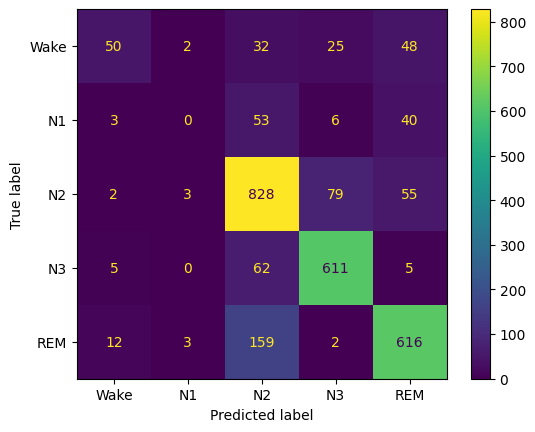

In [ ]:
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

best_accuracy = 0

for fold, (train_indices, val_indices) in enumerate(kf.split(X_train)):
    # Extract training and validation data
    X_train_fold, X_val_fold = X_train[train_indices], X_train[val_indices]
    y_train_fold, y_val_fold = y_train[train_indices], y_train[val_indices]

    # Create and train the classifier for this fold
    clf = XGBClassifier()
    clf.fit(X_train_fold, y_train_fold)

    # Make predictions on the validation set
    predictions = clf.predict(X_val_fold)

    # Compute performance metrics for current fold
    scores = {
        'balanced_accuracy': balanced_accuracy_score(y_val_fold, predictions),
        'cohen_kappa': cohen_kappa_score(y_val_fold, predictions),
        'macro_f1': f1_score(y_val_fold, predictions, average='macro')
    }

    print(f"Fold {fold + 1} Scores:", scores)

    # If the balanced accuracy score for this fold is better than the best so far, update best_accuracy
    if scores['balanced_accuracy'] > best_accuracy:
        best_accuracy = scores['balanced_accuracy']
        best_fold_predictions = predictions  # Store predictions for the best fold
        print(scores)

print(scores)
ConfusionMatrixDisplay.from_estimator(clf, X_test,y_test,display_labels = ['Wake','N1','N2','N3','REM'])

We can see that the confusion matrix still indicates a lot of confusion between N2 and REM. This might have been better with EOG recordings, or even with a better taking into account of the spindles, which could be a possibility for improving the training of this model. N1 phases are few in the sleep cycle, but they are also badly predicted. However, their low number is the reason why it does not impede the accuracy too much.
N3, which is deep sleep, seem to be the best predicted overall, apart from the confusions with N2, probably because its characteristics are more clear in the features : low frequencies, strong delta waves, but without other specificities (all the epochs for each predicted stage had quite strong low frequencies when plotted).



In [ ]:
# These were the codes used to generate MDI and permutation importance graphs to decide which features to cut (to run before cutting out the features !!)

# MDI Feature importance
mdi_importances = pd.Series(
    clf.feature_importances_, index=variable_list  # Ensure variable_list is OK before passing it for test, i.e. put back the removed features if needed !
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(25, 10))
mdi_importances.plot.barh()
ax.set_title("XGBClassifier Feature Importances (MDI)")
ax.figure.tight_layout()
plt.show()

# Permutation importance
print('Calculating permutation importances...')
result = permutation_importance(clf, X_test, y_test, n_repeats=50, random_state=0, scoring='f1_macro')
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(25, 10))
ax.boxplot(result.importances[sorted_idx].T, vert=False, labels=[variable_list[i] for i in sorted_idx])
ax.set_title("Permutation Importances (Test set)")
plt.xlabel('Decrease in Macro-F1')
fig.tight_layout()
plt.show()

### Prediction on the test data and submission to the contest

In the last part of the code, we applied the trained model to the test dataset to generate predictions, which will be used to evaluate the model's performance on unseen data, as we generate the submission.csv that was submitted to the contest.
For each record in the test dataset, we replicated the same feature extraction process as used in the training phase. Consistency in feature extraction between training and testing phases was very important as it generated a lot of issues when the features were not perfectly aligned.

All extracted features were concatenated in the order specified by variable_list, ensuring that the input to the model has a consistent format and structure as the data used during training.
The trained classifier (clf) was then used to predict sleep stages for each epoch of the EEG data. Predictions were stored along with a unique identifier for each epoch.


In [ ]:
predictions = []
for record in os.listdir("test_records"):
    record_number = int(record[-5])
    x = np.load(f'test_records/{record}')

    # Initialize the dictionary entry for this record's features
    data_for_record = {}

    # Process each EEG channel as in training
    eeg_channels = [x[:, 1:7501], x[:, 7501:15001], x[:, 15001:22501], x[:, 22501:30001], x[:, 30001:37501]]
    for i, eeg_data in enumerate(eeg_channels):
        spectral_power = get_relative_spectral_power_for_epoch(eeg_data)
        stats = compute_stats(eeg_data)
        time_features = time_domain_features(eeg_data)
        wavelet_feats = wavelet_features(eeg_data)


        # Update the record's feature set with channel-specific features

        channel_features = {**spectral_power, **stats, **time_features, **wavelet_feats}
        for feature_name, feature_value in channel_features.items():
            data_for_record[f'channel_{i}_{feature_name}'] = feature_value

    # Accelerometer data
    acc_data = x[:, 37501:42001]
    acc_features = accelerometer_features(acc_data)
    higher_order_acc_feats = higher_order_acc_features(acc_data)
    data_for_record.update({**acc_features, **higher_order_acc_feats})

    # Combine features in the order they appear in variable_list
    combined_features = np.array([data_for_record[feature] for feature in variable_list]).T

    # Debugging: Check the shape
    print("Shape of combined features for prediction:", combined_features.shape)

    preds = clf.predict(combined_features)
    for i, pred in enumerate(preds):
        predictions.append({"identifier": record_number * 10000 + i, 'target': pred})

predictions = pd.DataFrame(predictions)
print(predictions)

predictions.to_csv('/kaggle/working/submission.csv',index = None)

Shape of combined features for prediction: (847, 153)
Shape of combined features for prediction: (936, 153)
Shape of combined features for prediction: (863, 153)
      identifier  target
0          90000       4
1          90001       0
2          90002       0
3          90003       0
4          90004       0
...          ...     ...
2641       70858       4
2642       70859       4
2643       70860       0
2644       70861       4
2645       70862       0

[2646 rows x 2 columns]


### Conclusion

As a conclusion, we achieved a final accuracy of 0.58056, with 161 features. Considering the scores of the KFold, around 0.70, this can indicate overfitting of our model. While we did a quite extensive feature extraction and experimented with various machine learning models, we faced significant debugging challenges that limited our ability to use all the potential features. For example, all our tentatives to use yasa features, which seemed to hold a lot of potential, generated complicated dimensional bugs that we didn't have the time to analyze fully, so we decided to cut them out.

Our tests indicated that using all EEG channels for training did not substantially improve accuracy compared to using a subset (2 or 5 channels). This observation suggests that select channels may hold more discriminative power for sleep stage classification.
Taking only one component (x)  of the accelerometer appeared to yield near similar results than taking into account y and z components too. That may be because one movement suffice to qualify the wake stage, as the sleeper moves his head.

Though we tried deep learning models, our tests did not yield better results compared to traditional machine learning approaches.
The use of XGBoost was a significant improvement over more basic classifiers like linear models and random forests, highlighting the effectiveness of ensemble learning in this context.

Future work directions would include, first, focusing on incorporating the full spectrum of extracted features, especially those we had to omit while being convinced of their importance, like spindle-related features.
Using bandpassed signals with MNE, generally preprocessing the signal further, and exploring YASA (Yet Another Spindle Algorithm) features could offer more nuanced insights into the EEG data.

Adding EMG (Electromyography) or EOG (Electrooculography) data could significantly enhance the model's ability to differentiate between various sleep stages, especially in distinguishing REM sleep.
Finally, while we didn't manage to make deep learning outperform other models in this challenge, its capacities in handling complex patterns in biosignals would potentially make it a better method to treat this data.


(1) Patel, A. K., Reddy, V., Shumway, K. R., & Araujo, J. F. (2022). Physiology, sleep stages. In StatPearls. StatPearls Publishing.

(2) Louis-Philippe Marquis, Tyna Paquette, Cloé Blanchette-Carrière, Gaëlle Dumel, Tore Nielsen, REM Sleep Theta Changes in Frequent Nightmare Recallers, Sleep, Volume 40, Issue 9, September 2017, zsx110,

(3) De Gennaro, L., & Ferrara, M. (2003). Sleep spindles: an overview. Sleep medicine reviews, 7(5), 423-440.

